In [16]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# # for dirname, _, filenames in os.walk('/kaggle/input'):
# #     for filename in filenames:
# #         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [17]:
# !pip install dataloader

In [18]:

# data = sio.loadmat(
#     "/kaggle/input/datasets/wassefy/synthtext/SynthText/gt.mat",
#     squeeze_me=True,
#     struct_as_record=False
# )

In [19]:
import scipy.io as sio
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import numpy as np
import cv2
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class VGG16(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        if pretrained:
            vgg = models.vgg16_bn(
                weights=models.VGG16_BN_Weights.IMAGENET1K_V1
            )
        else:
            vgg = models.vgg16_bn(weights=None)

        features = list(vgg.features.children())

        self.block1 = nn.Sequential(*features[:7])
        self.block2 = nn.Sequential(*features[7:14])
        self.block3 = nn.Sequential(*features[14:24])
        self.block4 = nn.Sequential(*features[24:34])
        self.block5 = nn.Sequential(*features[34:44])

        self.block6 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(512, 1024, kernel_size=3, padding=6, dilation=6),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True)
        )

        if not pretrained:
            self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        s1 = self.block1(x) 
        s2 = self.block2(s1)
        s3 = self.block3(s2)
        s4 = self.block4(s3)
        s5 = self.block5(s4)
        s6 = self.block6(s5)
        return s1, s2, s3, s4, s5, s6
    

class UpConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        mid_channels = out_channels // 2
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=1),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class CRAFT(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        self.backbone = VGG16(pretrained=pretrained)

        self.upconv1 = UpConvBlock(1024 + 512, 256)
        self.upconv2 = UpConvBlock(256 + 512, 128)
        self.upconv3 = UpConvBlock(128 + 256, 64)
        self.upconv4 = UpConvBlock(64 + 128, 32)


        self.conv_cls = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 2, kernel_size=1),
        )

        self._initialize_decoder_weights()

    def _initialize_decoder_weights(self):
        for module in [self.upconv1, self.upconv2, self.upconv3, self.upconv4, self.conv_cls]:
            for m in module.modules():
                if isinstance(m, nn.Conv2d):
                    nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                    if m.bias is not None:
                        nn.init.constant_(m.bias, 0)
                elif isinstance(m, nn.BatchNorm2d):
                    nn.init.constant_(m.weight, 1)
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        s1, s2, s3, s4, s5, s6 = self.backbone(x)

        y = torch.cat([s6, s5], dim=1)
        y = F.interpolate(y, size=s4.shape[2:], mode="bilinear", align_corners=False)
        y = self.upconv1(y)

        y = torch.cat([y, s4], dim=1)
        y = F.interpolate(y, size=s3.shape[2:], mode="bilinear", align_corners=False)
        y = self.upconv2(y)

        y = torch.cat([y, s3], dim=1)
        y = F.interpolate(y, size=s2.shape[2:], mode="bilinear", align_corners=False)
        y = self.upconv3(y)

        y = torch.cat([y, s2], dim=1)
        y = F.interpolate(y, size=s1.shape[2:], mode="bilinear", align_corners=False)
        y = self.upconv4(y)

        y = self.conv_cls(y)

        return y.permute(0, 2, 3, 1)

In [ ]:
def generate_gaussian_kernel(size=64):
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    xx, yy = np.meshgrid(x, y)
    gauss = np.exp(-(xx**2 + yy**2) / (2 * 0.5**2))
    return gauss.astype(np.float32)

GAUSSIAN = generate_gaussian_kernel(64)

def create_region_heatmap(dst_quad, img_h, img_w):
    src = np.array([[0,0],[64,0],[64,64],[0,64]], dtype=np.float32)
    dst = dst_quad.astype(np.float32)
    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(GAUSSIAN, M, (img_w, img_h))

def make_heatmaps(charBB, img_h, img_w):
    region = np.zeros((img_h, img_w), dtype=np.float32)
    affinity = np.zeros((img_h, img_w), dtype=np.float32)

    # charBB (2, 4, N) to (N, 4, 2)
    boxes = charBB.transpose(2, 1, 0)

    for i, box in enumerate(boxes):
        region = np.maximum(region, create_region_heatmap(box, img_h, img_w))

        # midpoint quad between char i and char i+1
        if i + 1 < len(boxes):
            next_box = boxes[i + 1]
            aff_quad = np.array([
                (box[0] + box[1]) / 2,
                (next_box[0] + next_box[1]) / 2,
                (next_box[2] + next_box[3]) / 2,
                (box[2] + box[3]) / 2,
            ])
            affinity = np.maximum(affinity, create_region_heatmap(aff_quad, img_h, img_w))

    return region, affinity


In [ ]:
class SynthTextDataset(Dataset):
    def __init__(self, root, img_size=768):
        self.root = Path(root)
        self.img_size = img_size

        mat = sio.loadmat(str(self.root / "gt.mat"), squeeze_me=True, struct_as_record=False)
        self.imnames = mat["imnames"]
        self.charBBs = mat["charBB"]
        self.img_size = img_size

    def __len__(self):
        return len(self.imnames)

    def __getitem__(self, idx):
        img_path = self.root / self.imnames[idx]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w = img.shape[:2]
        charBB = self.charBBs[idx]
        if charBB.ndim == 2:
            charBB = charBB[:, :, None]


        scale = self.img_size / max(h, w)
        new_h, new_w = int(h * scale), int(w * scale)
        img = cv2.resize(img, (new_w, new_h))


        charBB = charBB.copy().astype(np.float32)
        charBB[0] *= (new_w / w)
        charBB[1] *= (new_h / h)  


        hm_h, hm_w = new_h // 2, new_w // 2
        charBB_half = charBB / 2.0
        region, affinity = make_heatmaps(charBB_half, hm_h, hm_w)


        pad_img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        pad_img[:new_h, :new_w] = img

        # Pad heatmaps
        hm_size = self.img_size // 2
        pad_region = np.zeros((hm_size, hm_size), dtype=np.float32)
        pad_affinity = np.zeros((hm_size, hm_size), dtype=np.float32)
        pad_region[:hm_h, :hm_w] = region
        pad_affinity[:hm_h, :hm_w] = affinity


        img_t = torch.from_numpy(pad_img).permute(2, 0, 1).float() / 255.0

        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img_t = (img_t - mean) / std

        gt = torch.stack([
            torch.from_numpy(pad_region),
            torch.from_numpy(pad_affinity)
        ], dim=0)

        return img_t, gt


In [24]:
def save_checkpoint(model, optimizer, epoch, loss, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss,
    }, path)

def load_checkpoint(model, optimizer, path):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    return ckpt["epoch"], ckpt["loss"]

In [ ]:
from torch.utils.data import Dataset, DataLoader, Subset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = SynthTextDataset("/kaggle/input/datasets/wassefy/synthtext/SynthText")
small_dataset = Subset(dataset, range(5000)) 
loader  = DataLoader(small_dataset, batch_size=4, shuffle=True,
                     num_workers=8, pin_memory=True, persistent_workers=True)

model = CRAFT(pretrained=True).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

EPOCHS = 5
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for step, (imgs, gts) in enumerate(loader):
        imgs = imgs.to(device)
        gts  = gts.to(device)   # (B, 2, H/2, W/2)

        preds = model(imgs)      # (B, H/2, W/2, 2) — your permute
        preds = preds.permute(0, 3, 1, 2)  # back to (B, 2, H/2, W/2)

        loss = criterion(preds, gts)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if step % 100 == 0:
            print(f"Epoch {epoch} | Step {step} | Loss {loss.item():.4f}")

    print(f"Epoch {epoch} done — avg loss: {total_loss/len(loader):.4f}")
    torch.save(model.state_dict(), f"craft_epoch{epoch}.pth")


In [26]:
def load_model(path, model, device):
    ckpt = torch.load(path, map_location=device)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    else:
        model.load_state_dict(ckpt)
    return model

model = CRAFT(pretrained=False).to(device)
model = load_model("/kaggle/input/models/kash2002/craft/pytorch/default/1/craft_epoch4_dynamic_5k.pth", model, device)
model.eval()

CRAFT(
  (backbone): VGG16(
    (block1): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size

In [ ]:
def get_word_boxes(region, affinity, region_thresh=0.9, affinity_thresh=0.8, padding=8):


    combined = np.clip(region + affinity, 0, 1)
    binary = ((region > region_thresh) | (combined > affinity_thresh)).astype(np.uint8)

    n_labels, labels = cv2.connectedComponents(binary, connectivity=4)

    boxes = []
    for label in range(1, n_labels):
        mask = (labels == label).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue

        rect = cv2.minAreaRect(contours[0])
        center, (w, h), angle = rect
        rect = (center, (w + 2 * padding, h + 2 * padding), angle)
        box  = cv2.boxPoints(rect)
        boxes.append(box)

    return boxes


def preprocess(img_path, img_size=768):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    scale = img_size / max(h, w)
    img = cv2.resize(img, (int(w * scale), int(h * scale)))

    t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    t = (t - mean) / std
    return t.unsqueeze(0).to(device), img

(384, 363) (384, 363) (768, 727, 3)


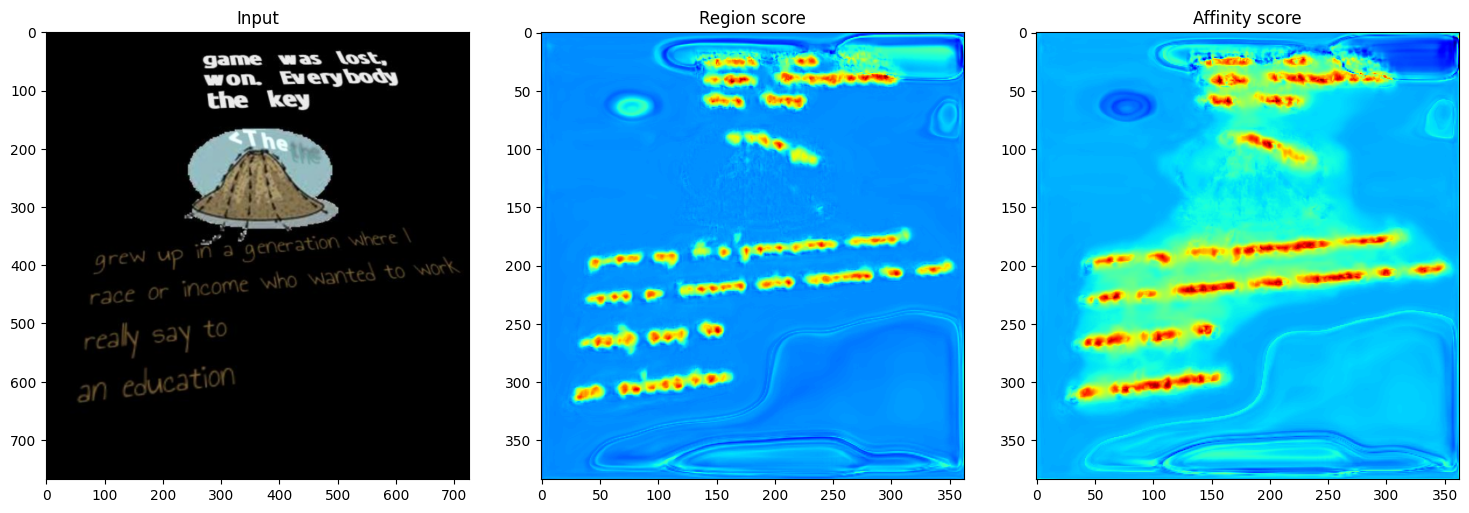

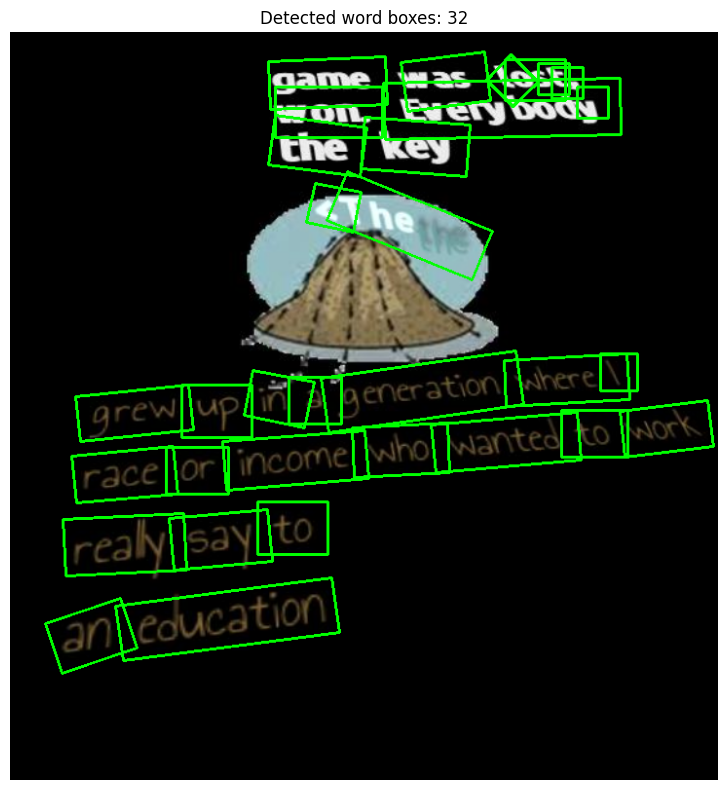

In [ ]:
path = "/kaggle/input/datasets/wassefy/synthtext/SynthText/1/ant+hill_100_1.jpg"
img_tensor, orig = preprocess(path)

with torch.no_grad():
    out = model(img_tensor)

region   = out[0, :, :, 0].cpu().numpy()
affinity = out[0, :, :, 1].cpu().numpy()

print(region.shape, affinity.shape, orig.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig);            axes[0].set_title("Input")
axes[1].imshow(region,   cmap="jet"); axes[1].set_title("Region score")
axes[2].imshow(affinity, cmap="jet"); axes[2].set_title("Affinity score")
plt.tight_layout()
plt.show()

pred_boxes = get_word_boxes(region, affinity, region_thresh=0.8, affinity_thresh=0.5)

h, w = orig.shape[:2]
hm_h, hm_w = region.shape
sx, sy = w / hm_w, h / hm_h

vis = orig.copy()
for box in pred_boxes:
    scaled = (box * np.array([sx, sy])).astype(np.int32)
    cv2.polylines(vis, [scaled], isClosed=True, color=(0, 255, 0), thickness=2)

plt.figure(figsize=(12, 8))
plt.imshow(vis)
plt.title(f"Detected word boxes: {len(pred_boxes)}")
plt.axis("off")
plt.tight_layout()
plt.show()


In [41]:
dataset = SynthTextDataset("/kaggle/input/datasets/wassefy/synthtext/SynthText")


In [46]:
from torch.utils.data import DataLoader, Subset


indices = torch.randperm(len(dataset))[:5000].tolist()

val_dataset = Subset(dataset, indices)
val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=8
)

criterion = nn.MSELoss()

model.eval()
val_loss = 0

print("Start")

count = 0
with torch.no_grad():
    for imgs, gts in val_loader:
        imgs = imgs.to(device)
        gts = gts.to(device)
        
        count += imgs.size(0)
        
        preds = model(imgs)
        preds = preds.permute(0, 3, 1, 2)

        loss = criterion(preds, gts)
        val_loss += loss.item()

avg_val_loss = val_loss / len(val_loader)
print(f"Validation Loss: {avg_val_loss:.4f}")

Start
Validation Loss: 0.0077
